# News Article Grouping Research

In this notebook, we develop and evaluate the **cross-encoder classifier** used in **Stage 3** of the news article grouping research pipeline.

## Cross-Encoder Classifier Development

The objective of this notebook is to train a model capable of **classifying whether a pair of articles refers to the same real-world event**. In this context, *event similarity* does not refer to general semantic similarity, but rather to whether both articles report on **the same underlying real-world occurrence**, potentially from different perspectives or media outlets.

The dataset structure can be represented as:

(A, A₁), (A, A₂), ..., (A, Aₖ) → [1, 0, ..., 1]

where each pair of articles receives a binary label:

- **1** — Both articles refer to the same event  
- **0** — The articles refer to different events

We conduct two main experiments to determine which configuration best suits the research objectives, in addition to smaller exploratory experiments performed during development. Both datasets contain **100,000 examples**, which are a subsample of the **WCEP dataset**, the primary dataset used throughout this research.

It is important to clarify that this subset **does not overlap and does not contain any repeated articles** from the subsample used in the main pipeline. This prevents the risk of **data leakage**, where the model could already know the label of a pair of articles during inference. By avoiding this overlap, we ensure that when the model is used in the main pipeline (**Stage 3**), it is evaluating **previously unseen data**.

1. **Headlines-Only Dataset**  
   This dataset contains pairs of article headlines. Each example consists of two headlines and a binary label indicating whether the pair refers to the same event.

2. **Headlines + Content Dataset**  
   This dataset follows the same structure as the previous one but also includes the **full article bodies**, providing additional contextual information.

## Experiment Design

### Hypothesis

> Including the **article content** will improve the model's precision, as the additional context may help the model better determine whether two articles describe the same real-world event.

### Pre-processing & Tokenization

Using the **Hugging Face Transformers** library, we convert the raw text into subword tokens compatible with **ModernBERT's vocabulary**. We adopt **ModernBERT** because it represents a significant evolution of the original BERT architecture and was trained on approximately **2 trillion tokens**. Importantly, it natively supports sequences of up to **8,192 tokens**.

> *Note: We experimented with different context lengths to balance computational cost with the ability to capture sufficient article context. Initially, we evaluate sequence lengths between **128 and 2,048 tokens** (depending on the experiment), as exploratory data analysis (EDA) indicates that most articles fall within this range. Additional experiments with different context sizes may be conducted in future iterations.*

### Fine-Tuning Strategy

Rather than relying on static embeddings, we perform **task-specific fine-tuning** of the model. This allows the model's weights to adapt to the nuances of **news reporting, political language, and framing differences across outlets**.

We experiment with **different numbers of unfrozen layers**, which may influence both training stability and the model's ability to specialize for the **event-matching classification task**.

### Hyperparameter Optimization (HPO)

We conduct hyperparameter searches over key training parameters, focusing primarily on:

- **Learning rate**
- **Weight decay**

The goal is to ensure **stable training and optimal convergence** for the **article pair classification task**.

### Evaluation & Analysis

Finally, we evaluate the trained models and analyze their performance in order to:

- Identify strengths and weaknesses of each dataset configuration  
- Validate the experimental hypothesis  
- Extract insights that may inform further improvements to the pipeline

## 0. Import Dependencies

In [ ]:
# Install packages needed for HPO + Training
!pip install optuna evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.2 MB/s eta 0:00:00


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import evaluate
import random
import optuna
import torch.nn.functional as F

from tqdm.notebook import tqdm
from datetime import datetime
from datasets import Dataset, DatasetDict
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback
from sklearn.metrics import confusion_matrix, classification_report
from optuna.pruners import MedianPruner
from google.colab import drive
from sklearn.model_selection import train_test_split

## 0.1 Setup Google Drive

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


### 0.2 Global Variables

In this section, we define the global variables that will be used throughout the notebook. The most important variable is `EXPERIMENT_TYPE`, which determines the execution mode of the notebook.

This variable can take one of two values:

- `headlines` - Processes the **headlines-only dataset**.
- `full` - Processes the dataset that includes **both headlines and article content**.

The purpose of this configuration is to make the repository as **reusable and flexible as possible**, allowing the same codebase to be executed with either dataset while requiring minimal modifications.

In [ ]:
# Paths
DATASET_PATH = "/content/drive/MyDrive/Research/articles_grouping/datasets/preprocessed/cross-encoder/output_3000_events.csv"
MODEL_NAME = "answerdotai/ModernBERT-base"
# Notebook Mode
EXPERIMENT_TYPE = "full"

## 1. Datasets Preparation & Pre-Processing

### 1.1 Loading & Transforming Data

In this step, we load the datasets from `.csv` files using **Pandas** and convert them into **Hugging Face `Dataset` objects** for efficient preprocessing and training.


In [ ]:
raw_df = pd.read_csv(filepath_or_buffer=DATASET_PATH)
raw_df = raw_df.dropna()

print(f"Experiment Type: '{EXPERIMENT_TYPE}'")
print(f"Shape of raw dataset: {raw_df.shape}")

Experiment Type: 'full'
Shape of raw dataset: (182027, 5)


#### Create Pairs DataFrame

In this sub-stage, we generate **100,000 article pairs**, evenly split between **positive and negative labels**, using the subsample described in the introduction of this notebook.

In [ ]:
TARGET_PAIRS_PER_CLASS = 50_000
MAX_PAIRS_PER_EVENT = 20

raw_df_indexed = raw_df.set_index("id")

# Positive pairs
positive_pairs = []

for event_id, group in tqdm(raw_df.groupby("event_id"), desc="Positive pairs"):
    ids = group["id"].tolist()
    if len(ids) < 2:
        continue
    row_map = raw_df_indexed.loc[ids].to_dict("index")
    pair_list = list(combinations(ids, 2))

    if len(pair_list) > MAX_PAIRS_PER_EVENT:
        pair_list = random.sample(pair_list, MAX_PAIRS_PER_EVENT)

    for id_a, id_b in pair_list:
        a, b = row_map[id_a], row_map[id_b]
        positive_pairs.append({
            "id_a": id_a, "headline_a": a["title"], "body_a": a["content"],
            "id_b": id_b, "headline_b": b["title"], "body_b": b["content"],
            "label": 1
        })

print(f"Generated {len(positive_pairs)} positive pairs")

# If still over target, subsample
if len(positive_pairs) > TARGET_PAIRS_PER_CLASS:
    random.seed(42)
    positive_pairs = random.sample(positive_pairs, TARGET_PAIRS_PER_CLASS)
    print(f"Subsampled to {len(positive_pairs)} positive pairs")

positive_pairs_df = pd.DataFrame(positive_pairs)

positive_pair_ids = {
    tuple(sorted((r["id_a"], r["id_b"])))
    for r in positive_pairs
}

# Negative Pairs
id_to_event = raw_df.set_index("id")["event_id"].to_dict()
all_articles = np.array(raw_df["id"].tolist())

num_negative_to_generate = len(positive_pairs_df)
print(f"Generating {num_negative_to_generate} negative pairs...")

negative_pairs = []
negative_pair_ids = set()
progress_bar = tqdm(total=num_negative_to_generate, desc="Negative pairs")

BATCH = 10_000
while len(negative_pairs) < num_negative_to_generate:
    samples = np.random.choice(all_articles, size=(BATCH, 2), replace=True)

    for id_a, id_b in samples:
        if len(negative_pairs) >= num_negative_to_generate:
            break
        if id_a == id_b:
            continue
        key = tuple(sorted((id_a, id_b)))
        if key in positive_pair_ids or key in negative_pair_ids:
            continue
        if id_to_event[id_a] == id_to_event[id_b]:
            continue

        a, b = raw_df_indexed.loc[id_a], raw_df_indexed.loc[id_b]
        negative_pairs.append({
            "id_a": id_a, "headline_a": a["title"], "body_a": a["content"],
            "id_b": id_b, "headline_b": b["title"], "body_b": b["content"],
            "label": 0
        })
        negative_pair_ids.add(key)
        progress_bar.update(1)

negative_pairs_df = pd.DataFrame(negative_pairs)

In [ ]:
final_pairs_df = pd.concat([positive_pairs_df, negative_pairs_df], ignore_index=True)
final_pairs_df = final_pairs_df.sample(frac=1).reset_index(drop=True)

#### Create Dataset

In [ ]:
raw_dataset = Dataset.from_pandas(final_pairs_df)
raw_dataset

In [ ]:
train_testvalid = raw_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = train_testvalid["train"]

test_valid = train_testvalid["test"].train_test_split(test_size=0.5, seed=42)
valid_dataset = test_valid["train"]
test_dataset = test_valid["test"]

dataset = DatasetDict({
    "train": train_dataset,
    "validation": valid_dataset,
    "test": test_dataset
})

### 1.2 Tokenization

In this section, we load the **pre-trained tokenizer** corresponding to the transformer model used in our experiments. The tokenizer converts the raw text into subword tokens compatible with the model's vocabulary. We then apply a custom preprocessing function that tokenizes each dataset example, producing the tokenized inputs required for training.

The **maximum sequence length (context size)** differs between the two experimental setups, as the amount of text available in each dataset varies significantly.

For the **headlines-only dataset**, we use a maximum sequence length of **128 tokens**. Since each example contains only `headline_a` and `headline_b`, concatenated using the `[SEP]` token, a large context window is unnecessary. During the exploratory data analysis (EDA), we observed that the longest headline contains **30 words**, meaning that the combined tokenized input typically falls well below the 128-token limit (roughly **100-120 tokens** after tokenization). This configuration avoids excessive padding, reduces computational overhead, and allows faster **hyperparameter optimization (HPO)** and model training while still leaving sufficient margin should slightly longer headlines appear in the future.

For the **headlines + content dataset**, the situation is different. Each example includes the **headlines and the full article bodies for both articles**, which are also concatenated before tokenization. As a result, a substantially larger context window is required. We begin our experiments with a **maximum sequence length of 2,048 tokens**, which allows us to capture the majority of article content while maintaining manageable computational costs.

If the tokenized input exceeds the specified maximum sequence length, the excess tokens are **truncated** during preprocessing.

In [ ]:
print(f"Loading Tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded sucessfully")

In [ ]:
def tokenize_examples(examples):
    """
    Handles tokenization for both 'headlines' and 'full' experiment types.
    """
    if EXPERIMENT_TYPE == "full":
        text_a = [f"{h} {c}" for h, c in zip(examples["headline_a"], examples["body_a"])]
        text_b = [f"{h} {c}" for h, c in zip(examples["headline_b"], examples["body_b"])]
    else:
        text_a = examples["headline_a"]
        text_b = examples["headline_b"]

    return tokenizer(
        text=text_a,
        text_pair=text_b,
        truncation=True,
        max_length=2048 if EXPERIMENT_TYPE == "full" else 128
    )

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
dataset = dataset.map(tokenize_examples, batched=True, desc="Tokenazing dataset")

## 2. Model Architecture

As introduced earlier in this notebook, we use **ModernBERT**, a pre-trained transformer model from the BERT family, as the backbone of our classifier.

We initially **freeze all pre-trained layers** to preserve the linguistic knowledge learned during large-scale pre-training. We then progressively **fine-tune the model for our specific task** by unfreezing the last *N* transformer layers. This approach allows the upper layers of the network to adapt to the **article pair event-classification task**, while the lower layers retain their general language representations.

> *Architecture Note: For this stage, we do not introduce additional dense layers or custom task-specific heads. Instead, we rely on the **standard sequence classification head provided by the Hugging Face Transformers implementation**, which consists of a linear layer applied to the pooled representation of the transformer output.*

In [ ]:
NUM_LABELS = 2

def init_model():
    """
    Initialices transformer model.
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    )

    # Freeze embeddings
    for param in model.model.embeddings.parameters():
        param.requires_grad = False

    # Freeze all layers
    for param in model.model.layers.parameters():
        param.requires_grad = False

    if EXPERIMENT_TYPE == "full":
        # Unfreeze last 2 layers (layers 20-21)
        for param in model.model.layers[20].parameters():
            param.requires_grad = True
        for param in model.model.layers[21].parameters():
            param.requires_grad = True
    else:
        # Unfreeze last 3 layers (layers 19-20-21)
        for param in model.model.layers[19].parameters():
            param.requires_grad = True
        for param in model.model.layers[20].parameters():
            param.requires_grad = True
        for param in model.model.layers[21].parameters():
            param.requires_grad = True

    # Unfreeze the head and classifier (always trainable for fine-tuning)
    for param in model.head.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    print(f"Sucessfully initialized `{MODEL_NAME}` model")
    model.resize_token_embeddings(len(tokenizer))

    return model

> *Note: The number of unfrozen layers differs between the two datasets. For the **headlines-only dataset**, we unfreeze **3 transformer layers**, since the inputs are significantly shorter than those in the **full-content dataset**, where we unfreeze **2 layers**.*

In [ ]:
# Temporal instance of the model to check parameters count
temp_model = init_model()

total_params = sum(p.numel() for p in temp_model.parameters())
trainable_params = sum(p.numel() for p in temp_model.parameters() if p.requires_grad)

print("Model Parameters Count:")
print(f"Total: {total_params}")
print(f"Trainable: {trainable_params}")
print(f"Frozen: {total_params - trainable_params}")

del temp_model

**Headline-Only Model**
| Parameter Type | Number of Parameters |
| -------------- | -------------------- |
| **Total**      | 149,606,402          |
| **Trainable**  | 15,638,018           |
| **Frozen**     | 133,968,384          |

<br/>

**Headline + Content Model**
| Parameter Type | Number of Parameters |
| -------------- | -------------------- |
| **Total**      | 149,606,402          |
| **Trainable**  | 10,622,978           |
| **Frozen**     | 138,983,424          |


## 3. Hyperparameter Optimization (HPO) + Training

### Evaluation Metrics

Since both datasets exhibit a **significant class imbalance**, our evaluation will focus primarily on the **F1-score**, which balances **precision** and **recall** and provides a more informative measure of performance than accuracy in imbalanced classification settings.

In addition to the F1-score, we also report **precision** and **recall** to better understand the model's behavior when identifying article pairs that refer to the same event.

In [ ]:
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    """
    Computes metrics for our transformer model. It uses a combination of 'precision', 'recall' and 'f1' metrics.

    Args:
        eval_pred (): Predictions.

    Returns:
        Dictionary containing the metrics.
    """
    # Destructure logits and labels
    logits, labels = eval_pred
    # Generate predictions
    predictions = np.argmax(logits, axis=-1)

    results = {}
    results.update(precision.compute(predictions=predictions, references=labels, average="weighted"))
    results.update(recall.compute(predictions=predictions, references=labels, average="weighted"))
    results.update(f1.compute(predictions=predictions, references=labels, average="weighted"))

    return results

### HPO + Trainer Setup

We will first create the default `TrainingArguments` for our model that will be use to find the optimal hyperparameters using `.hyperparameter_search()`. Once we find the best for our scenario, we will train the final fine-tuned version of our model.

**Primary Hyperparameters**

* Learning Rate (learning_rate) - Controls the step size during gradient descent, between 1e-5 to 5e-5 (log scale).

* Training Epochs (num_train_epochs) - Number of complete passes through the training dataset, between 1 and 5.

* Batch Size (per_device_train_batch_size) - Number of samples processed together in one forward/backward pass, range: [16, 32].

**Secondary Hyperparameters (Optional)**

* Warmup Ratio (warmup_ratio) - Fraction of training steps to gradually increase learning rate, between 0.05 and 0.15.

* Weight Decay (weight_decay) - L2 regularization to prevent overfitting, between 1e-3 to 1e-1.

* Gradient Accumulation (gradient_accumulation_steps) - Simulate larger batch sizes by accumulating gradients, range: [1, 2].

In [ ]:
def objective(trial):
    """
    Optuna's objective function to create possible hyperparameters to search.
    """
    training_args = TrainingArguments(
        output_dir=f"./hpo_results/trial_{trial.number}",
        num_train_epochs=3,
        max_steps=1000,
        eval_strategy="steps",
        eval_steps=100,
        save_strategy="steps",
        save_steps=100,
        load_best_model_at_end=True,
        save_total_limit=1,
        per_device_train_batch_size=trial.suggest_categorical("train_bs", [16, 32]),
        gradient_accumulation_steps=trial.suggest_categorical("grad_accum", [1, 2]),
        learning_rate=trial.suggest_float("lr", 1e-5, 5e-5, log=True),
        weight_decay=trial.suggest_float("weight_decay", 1e-3, 1e-1, log=True),
        warmup_ratio=trial.suggest_float("warmup_ratio", 0.05, 0.15),

        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        bf16=True,
        dataloader_num_workers=2,
    )

    trainer = Trainer(
        model_init=init_model,
        args=training_args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["val"],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
    )

    trainer.train()
    metrics = trainer.evaluate()

    return metrics["eval_f1"]

### Setup HPO Tracking

In [ ]:
DB_DIR = "/content/drive/MyDrive/Research/articles_grouping/hpo_full"
os.makedirs(DB_DIR, exist_ok=True)

db_path = f"sqlite:///{DB_DIR}/optuna.db"

if os.path.exists(f"{DB_DIR}/optuna.db"):
    print(f"Optuna database found at {DB_DIR}/optuna.db. Attempting to load existing study.")
else:
    print(f"Optuna database not found at {DB_DIR}/optuna.db. A new study will be created.")

### Run HPO study

In [ ]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=100, interval_steps=100),
    storage=db_path,
    load_if_exists=True,
)

NUM_TRIALS = 10
study.optimize(objective, n_trials=NUM_TRIALS)

### HPO Results

#### 1. Headlines-Only Dataset

**Best F1-Score:** 0.9115

| Hyperparameter | Value |
|----------------|------|
| Train Batch Size | 32 |
| Gradient Accumulation | 2 |
| Learning Rate | 3.538461259525519e-05 |
| Weight Decay | 0.002508115686045232 |
| Warmup Ratio | 0.10142344384136115 |

> *Note: This HPO ran on a NVIDIA L4 with 22.5GB of vram and 53GB of system ram.*

<br/>

#### 2. Headlines + Content Dataset

**Best F1-Score:** 0.8560

| Hyperparameter | Value |
|----------------|------|
| Train Batch Size | 32 |
| Gradient Accumulation | 2 |
| Learning Rate | 4.221409440229581e-05 |
| Weight Decay | 0.015696396388661146 |
| Warmup Ratio | 0.14218742350231167 |

> *Note: This HPO ran on a NVIDIA L4 with 22.5GB of vram and 53GB of system ram.*

## 4. Model Evaluation

Using the hyperparameters obtained from the **best trial during hyperparameter optimization (HPO)**, we train a final version of the model and evaluate its performance on the evaluation dataset.

In addition, we conduct **error analysis** to better understand the types of mistakes made by the model and to identify potential areas for improvement in future iterations.

In [ ]:
if EXPERIMENT_TYPE == "full":
    best_hyperparameters = {
        "num_train_epochs": 2,
        "train_bs": 32,
        "eval_bs": 32,
        "grad_accum": 2,
        "lr": 4.221409440229581e-05,
        "weight_decay": 0.015696396388661146,
        "warmup_ratio": 0.14218742350231167,
    }
else:
    best_hyperparameters = {
        "num_train_epochs": 2,
        "train_bs": 32,
        "eval_bs": 64,
        "grad_accum": 2,
        "lr": 3.538461259525519e-05,
        "weight_decay": 0.002508115686045232,
        "warmup_ratio": 0.10142344384136115,
    }

In [ ]:
# Setup final training parameters
final_training_params = {
    "num_train_epochs": best_hyperparameters["num_train_epochs"],
    "learning_rate": best_hyperparameters["lr"],
    "per_device_train_batch_size": best_hyperparameters["train_bs"],
    "gradient_accumulation_steps": best_hyperparameters["grad_accum"],
    "per_device_eval_batch_size": best_hyperparameters["eval_bs"],
    "weight_decay": best_hyperparameters["weight_decay"],
    "warmup_ratio": best_hyperparameters["warmup_ratio"],
}

final_training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    max_steps=-1,

    num_train_epochs=final_training_params["num_train_epochs"],
    learning_rate=final_training_params["learning_rate"],
    per_device_train_batch_size=final_training_params["per_device_train_batch_size"],
    gradient_accumulation_steps=final_training_params["gradient_accumulation_steps"],
    per_device_eval_batch_size=final_training_params["per_device_eval_batch_size"],
    weight_decay=final_training_params["weight_decay"],
    warmup_ratio=final_training_params["warmup_ratio"],

    logging_steps=100,
    save_total_limit=2,
    bf16=True
)

# Create final trainer instance
final_trainer = Trainer(
    model_init=init_model,
    args=final_training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

# Train final model
final_trainer.train()
# Evaluate final model
test_results = final_trainer.evaluate(dataset["test"])

In [ ]:
predictions_output = final_trainer.predict(dataset["test"])

y_true = predictions_output.label_ids
logits = torch.tensor(predictions_output.predictions)
probs = torch.softmax(logits, dim=-1)[:, 1]


BEST_THRESHOLD = 0.5
y_pred = (probs >= BEST_THRESHOLD).long().numpy()

print(classification_report(y_true, y_pred, target_names=["Different Event", "Same Event"]))

### 4.1 Evaluation Results

#### 1. Headlines-Only Dataset

This section presents the evaluation results for the **Headlines-Only dataset**, where the model receives only article headlines as input when determining whether two articles refer to the same real-world event. The results indicate that even with limited contextual information, the model is able to achieve strong performance, suggesting that headlines alone often contain sufficient signals for identifying event-level similarity between articles.

<br/>

| Metric | Value |
|------|------|
| Eval Loss | 0.1851 |
| Precision | 0.9278 |
| Recall | 0.9275 |
| F1-Score | 0.9275 |
| Epoch | 2 |

<br/>

| Class | Precision | Recall | F1-Score | Support |
|------|------|------|------|------|
| Different Event | 0.91 | 0.94 | 0.93 | 4915 |
| Same Event | 0.94 | 0.92 | 0.93 | 5085 |
| **Accuracy** | — | — | **0.93** | 10000 |
| **Macro Avg** | 0.93 | 0.93 | 0.93 | 10000 |
| **Weighted Avg** | 0.93 | 0.93 | 0.93 | 10000 |


<br/>

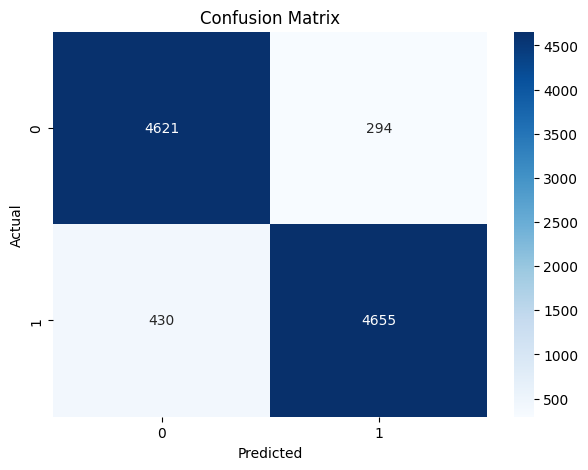

<br/>

---

<br/>

#### 2. Headlines + Content Dataset

This section presents the evaluation results for the **Headlines + Content dataset**, where the model receives both the **article headlines and the full article bodies** as input when determining whether two articles refer to the same real-world event. The goal of this configuration is to evaluate whether additional contextual information from the article content improves the model's ability to correctly classify event-level similarity between article pairs.

<br/>

| Metric | Value |
|------|------|
| Eval Loss | 0.2272 |
| Precision | 0.9088 |
| Recall | 0.9087 |
| F1-Score | 0.9086 |
| Epoch | 2 |

<br/>

| Class | Precision | Recall | F1-Score | Support |
|------|------|------|------|------|
| Different Event | 0.90 | 0.92 | 0.91 | 5019 |
| Same Event | 0.92 | 0.90 | 0.91 | 4981 |
| **Accuracy** | — | — | **0.91** | 10000 |
| **Macro Avg** | 0.91 | 0.91 | 0.91 | 10000 |
| **Weighted Avg** | 0.91 | 0.91 | 0.91 | 10000 |

<br/>

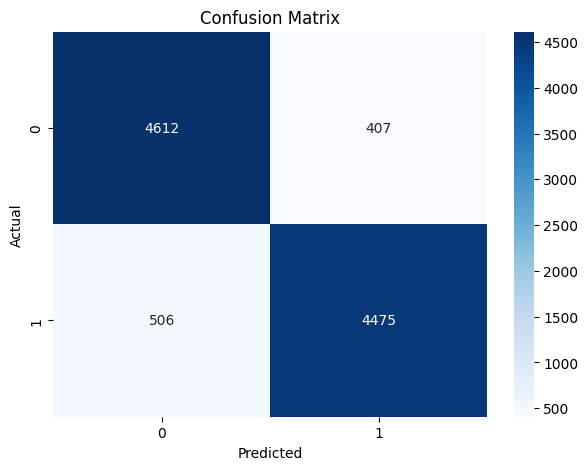


---

# Conclusion

Both experiments yield similar results, with the **headlines-only configuration outperforming the headlines + content setup by ~2% in several metrics**. Based on these findings, we conclude that the **most effective approach for this task is to use only article headlines**, as it requires significantly less input context. This allows the model to run efficiently on **smaller hardware** or to operate **extremely quickly on more powerful GPUs**.

Based on these results, the **headlines-only configuration provides the best balance between performance, efficiency, and robustness** for the event-matching classification task.

> *Note: A post-hoc filtering step could potentially improve performance for both datasets. In a small exploratory experiment, we observed an improvement of approximately **~3%**. However, due to the structure of the main dataset—where articles do not contain publication timestamps or article dates—we were unable to perform this experiment at scale.*

In conclusion, the **fine-tuned transformer model trained on article headlines represents the most effective configuration identified in this study**. This model will therefore be used in **Stage 3, Part 1 of the news article grouping research pipeline**.